# Original TeleSABRE vs BLaRTSABRE

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as sp_stats

plt.rcParams.update({
    "figure.dpi": 150,
    "figure.figsize": (12, 6),
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 10,
})

C_BLART = "#2563eb"
C_TELE  = "#e11d48"

In [2]:
BLART_PATH = "blartsabre_improved.json"
TELE_PATH  = "og_telesabre_opt_true.json"

with open(BLART_PATH) as f:
    blart_raw = json.load(f)
with open(TELE_PATH) as f:
    tele_raw = json.load(f)

# Handle both list-of-dicts and dict-of-dicts
if isinstance(blart_raw, dict):
    blart_raw = list(blart_raw.values())
if isinstance(tele_raw, dict):
    tele_raw = list(tele_raw.values())

# Match circuits by name
blart_by_name = {r["name"]: r for r in blart_raw}
tele_by_name  = {r["name"]: r for r in tele_raw}
names = sorted(set(blart_by_name) & set(tele_by_name))

blart = [blart_by_name[n] for n in names]
tele  = [tele_by_name[n] for n in names]

print(f"{len(names)} circuits")
for n in names:
    print(f"  {n}")

12 circuits
  ae_nativegates_ibm_qiskit_opt3_25
  ae_nativegates_ibm_qiskit_opt3_64
  ghz_nativegates_ibm_qiskit_opt3_25
  ghz_nativegates_ibm_qiskit_opt3_64
  graphstate_nativegates_ibm_qiskit_opt3_25
  graphstate_nativegates_ibm_qiskit_opt3_64
  qft_nativegates_ibm_qiskit_opt3_25
  qft_nativegates_ibm_qiskit_opt3_64
  qnn_nativegates_ibm_qiskit_opt3_25
  qnn_nativegates_ibm_qiskit_opt3_64
  random_nativegates_ibm_qiskit_opt3_25
  random_nativegates_ibm_qiskit_opt3_64


In [3]:
# Original circuit properties
og_cx     = np.array([b["og_cx"] for b in blart])
og_depth  = np.array([b["og_depth"] for b in blart])
og_size   = np.array([b["og_size"] for b in blart])
num_qubits = np.array([b["num_qubits"] for b in blart])

# BLART SABRE
b_swaps        = np.array([b["mapped_swaps"] for b in blart])
b_swaps_local  = np.array([b["mapped_swaps_local"] for b in blart])
b_swaps_remote = np.array([b["mapped_swaps_remote"] for b in blart])
b_cx_remote    = np.array([b["mapped_cx_remote"] for b in blart])
b_cx_local     = np.array([b["mapped_cx_local"] for b in blart])
b_depth        = np.array([b["mapped_depth"] for b in blart])
b_time         = np.array([b["mapping_time"] for b in blart])

# TeleSABRE
t_swaps     = np.array([t["mapped_swaps"] for t in tele])
t_teleports = np.array([t["mapped_teleports"] for t in tele])
t_telegates = np.array([t["mapped_telegates"] for t in tele])
t_depth     = np.array([t["mapped_depth"] for t in tele])
t_time      = np.array([t["mapping_time"] for t in tele])

# Derived: inter-core ops
b_remote_ops = b_swaps_remote + b_cx_remote
t_remote_ops = t_teleports + t_telegates

# Depth overhead
b_depth_ratio = b_depth / og_depth
t_depth_ratio = t_depth / og_depth

In [4]:
def short_name(name, max_len=25):
    name = name.replace("_nativegates_ibm_qiskit_opt3", "")
    name = name.replace("_nativegates_ibm_qiskit", "")
    return name[:max_len]

print(f"{'Circuit':<20} {'Qb':>3} {'OG_CX':>6} │ {'B_Rem':>6} {'T_Rem':>6} {'Δ':>6} │ {'B_Swp':>6} {'T_S+T':>6} {'Δ':>6} │ {'B_Dep':>6} {'T_Dep':>6} {'Δ':>7} │ {'B_t(s)':>7} {'T_t(s)':>7}")
print("─" * 130)

t_swaps_teleports = t_swaps + t_teleports

for i, name in enumerate(names):
    print(f"{short_name(name):<20} {num_qubits[i]:>3} {og_cx[i]:>6} │ "
          f"{b_remote_ops[i]:>6.0f} {t_remote_ops[i]:>6.0f} {b_remote_ops[i]-t_remote_ops[i]:>+6.0f} │ "
          f"{b_swaps[i]:>6.0f} {t_swaps_teleports[i]:>6.0f} {b_swaps[i]-t_swaps_teleports[i]:>+6.0f} │ "
          f"{b_depth[i]:>6.0f} {t_depth[i]:>6.0f} {b_depth[i]-t_depth[i]:>+7.0f} │ "
          f"{b_time[i]:>7.1f} {t_time[i]:>7.1f}")

print("─" * 130)
print(f"{'MEAN':<20} {'':>3} {'':>6} │ "
      f"{b_remote_ops.mean():>6.1f} {t_remote_ops.mean():>6.1f} {(b_remote_ops-t_remote_ops).mean():>+6.1f} │ "
      f"{b_swaps.mean():>6.1f} {t_swaps_teleports.mean():>6.1f} {(b_swaps-t_swaps_teleports).mean():>+6.1f} │ "
      f"{b_depth.mean():>6.1f} {t_depth.mean():>6.1f} {(b_depth-t_depth).mean():>+7.1f} │ "
      f"{b_time.mean():>7.1f} {t_time.mean():>7.1f}")
print(f"{'MEDIAN':<20} {'':>3} {'':>6} │ "
      f"{np.median(b_remote_ops):>6.1f} {np.median(t_remote_ops):>6.1f} {np.median(b_remote_ops-t_remote_ops):>+6.1f} │ "
      f"{np.median(b_swaps):>6.1f} {np.median(t_swaps_teleports):>6.1f} {np.median(b_swaps-t_swaps_teleports):>+6.1f} │ "
      f"{np.median(b_depth):>6.1f} {np.median(t_depth):>6.1f} {np.median(b_depth-t_depth):>+7.1f} │ "
      f"{np.median(b_time):>7.1f} {np.median(t_time):>7.1f}")

Circuit               Qb  OG_CX │  B_Rem  T_Rem      Δ │  B_Swp  T_S+T      Δ │  B_Dep  T_Dep       Δ │  B_t(s)  T_t(s)
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
ae_25                 25    558 │     59     19    +40 │    178    211    -33 │    867    518    +349 │   180.5    20.6
ae_64                 64   1962 │    325      0   +325 │    980    200   +780 │   2617    200   +2417 │  3248.1   164.6
ghz_25                25     24 │      4      2     +2 │     12      9     +3 │     49     30     +19 │     0.4     0.5
ghz_64                64     63 │     30      7    +23 │     97    106     -9 │    213     81    +132 │     4.2     6.3
graphstate_25         25     25 │      2      4     -2 │      6     14     -8 │     25     39     -14 │     1.9     2.1
graphstate_64         64     64 │     25     42    -17 │     71    400   -329 │     61    309    -248 │    58.5   926.2
qft_25                25    5

> B_Rem = mapped_swaps_remote + mapped_cx_remote

> T_Rem = mapped_teleports + mapped_telegates

> B_Swp = mapped_swaps

> T_S+T = mapped_swaps + mapped_teleports

In [5]:
print(f"{'Circuit':<20} │ {'B_Swp':>6} {'T_S+T':>6} {'✓?':>3} │ {'B_RSw':>6} {'T_Tel':>6} {'✓?':>3} │ {'B_RCX':>6} {'T_TG':>6} {'✓?':>3}")
print("─" * 90)

t_swaps_teleports = t_swaps + t_teleports
goals = {"swaps": 0, "remote_swap": 0, "remote_cx": 0}

for i, name in enumerate(names):
    g1 = "✓" if b_swaps[i] < t_swaps_teleports[i] else "✗"
    g2 = "✓" if b_swaps_remote[i] < t_teleports[i] else "✗"
    g3 = "✓" if b_cx_remote[i] < t_telegates[i] else "✗"
    if g1 == "✓": goals["swaps"] += 1
    if g2 == "✓": goals["remote_swap"] += 1
    if g3 == "✓": goals["remote_cx"] += 1

    print(f"{short_name(name):<20} │ "
          f"{b_swaps[i]:>6.0f} {t_swaps_teleports[i]:>6.0f} {g1:>3} │ "
          f"{b_swaps_remote[i]:>6.0f} {t_teleports[i]:>6.0f} {g2:>3} │ "
          f"{b_cx_remote[i]:>6.0f} {t_telegates[i]:>6.0f} {g3:>3}")

print("─" * 90)
n = len(names)
print(f"\nGoal scoreboard:")
print(f"  Total SWAPs < T_S+T:      {goals['swaps']}/{n} circuits")
print(f"  Remote SWAPs < Teleports:  {goals['remote_swap']}/{n} circuits")
print(f"  Remote CX < Telegates:     {goals['remote_cx']}/{n} circuits")

Circuit              │  B_Swp  T_S+T  ✓? │  B_RSw  T_Tel  ✓? │  B_RCX   T_TG  ✓?
──────────────────────────────────────────────────────────────────────────────────────────
ae_25                │    178    211   ✓ │     37     17   ✗ │     22      2   ✗
ae_64                │    980    200   ✗ │    255      0   ✗ │     70      0   ✗
ghz_25               │     12      9   ✗ │      4      2   ✗ │      0      0   ✗
ghz_64               │     97    106   ✓ │     28      6   ✗ │      2      1   ✗
graphstate_25        │      6     14   ✓ │      1      3   ✓ │      1      1   ✗
graphstate_64        │     71    400   ✓ │     22     34   ✓ │      3      8   ✓
qft_25               │    211    314   ✓ │     63     48   ✗ │     50      8   ✗
qft_64               │    921    199   ✗ │    219      0   ✗ │     66      2   ✗
qnn_25               │    388    474   ✓ │    106     48   ✗ │    108     12   ✗
qnn_64               │   2973   4059   ✓ │    813    344   ✗ │    540    279   ✗
random_25         

In [6]:
def bar_compare(blart_vals, tele_vals, ylabel, title, blart_label="BLART SABRE", tele_label="TeleSABRE"):
    x = np.arange(len(names))
    w = 0.35
    fig, ax = plt.subplots()
    ax.bar(x - w/2, blart_vals, w, label=blart_label, color=C_BLART, edgecolor="white")
    ax.bar(x + w/2, tele_vals, w, label=tele_label, color=C_TELE, edgecolor="white")
    ax.set_xticks(x)
    ax.set_xticklabels([short_name(n) for n in names], rotation=45, ha="right")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    fig.tight_layout()
    plt.show()

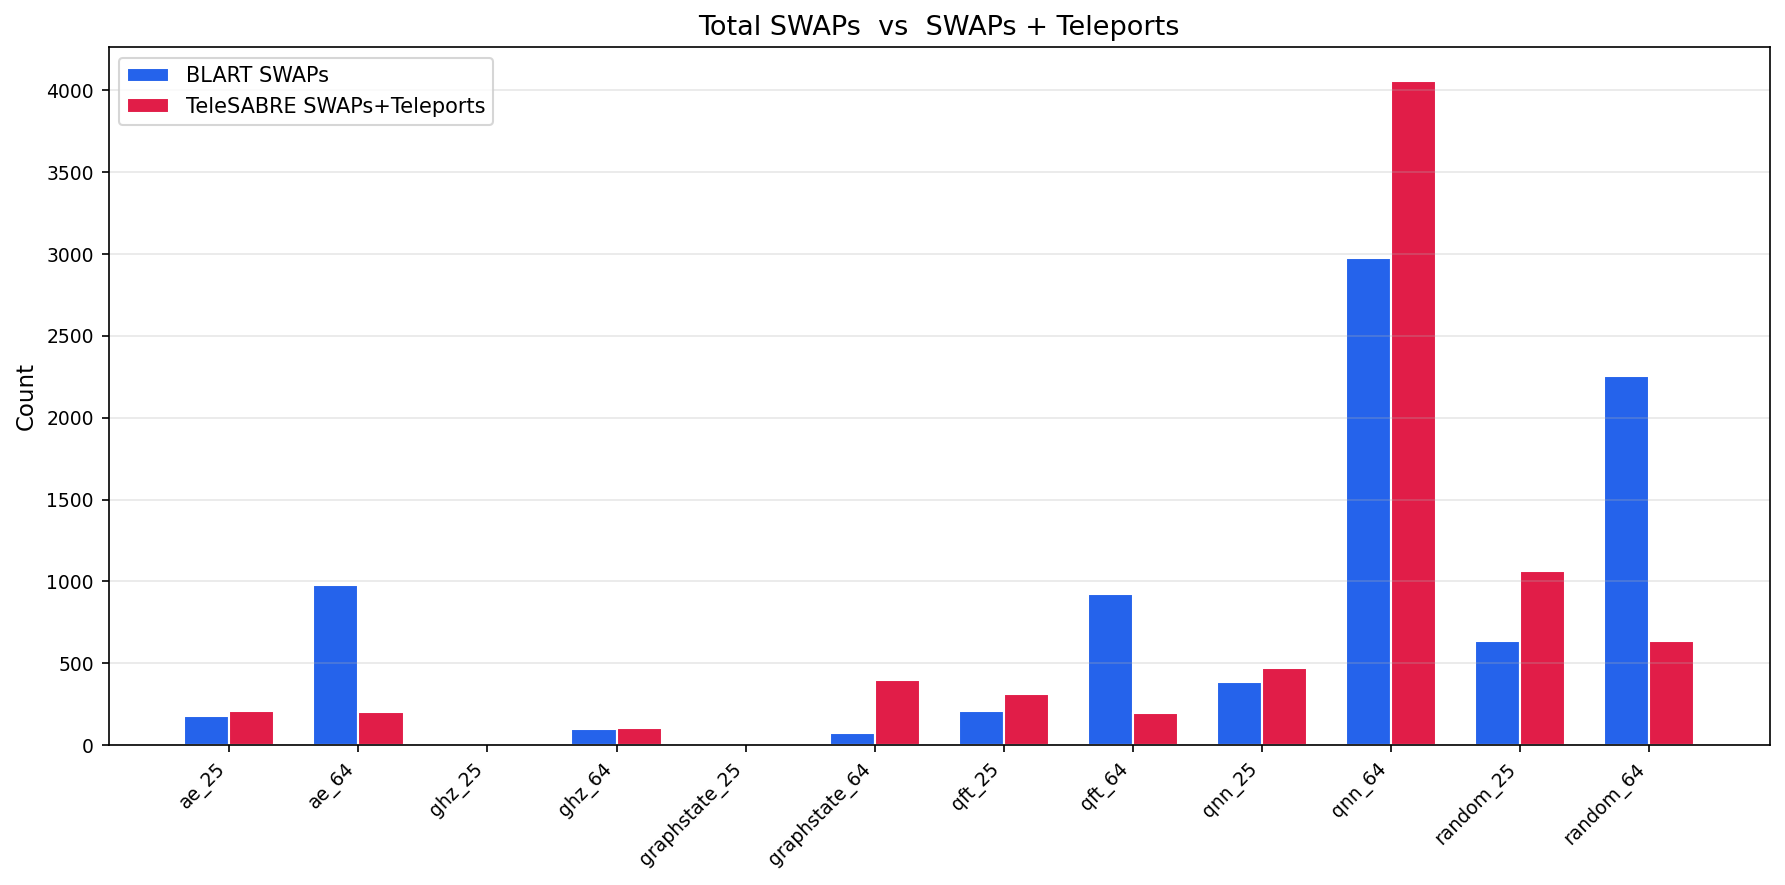

In [7]:
bar_compare(b_swaps, t_swaps + t_teleports,
            "Count", "Total SWAPs  vs  SWAPs + Teleports",
            blart_label="BLART SWAPs", tele_label="TeleSABRE SWAPs+Teleports")

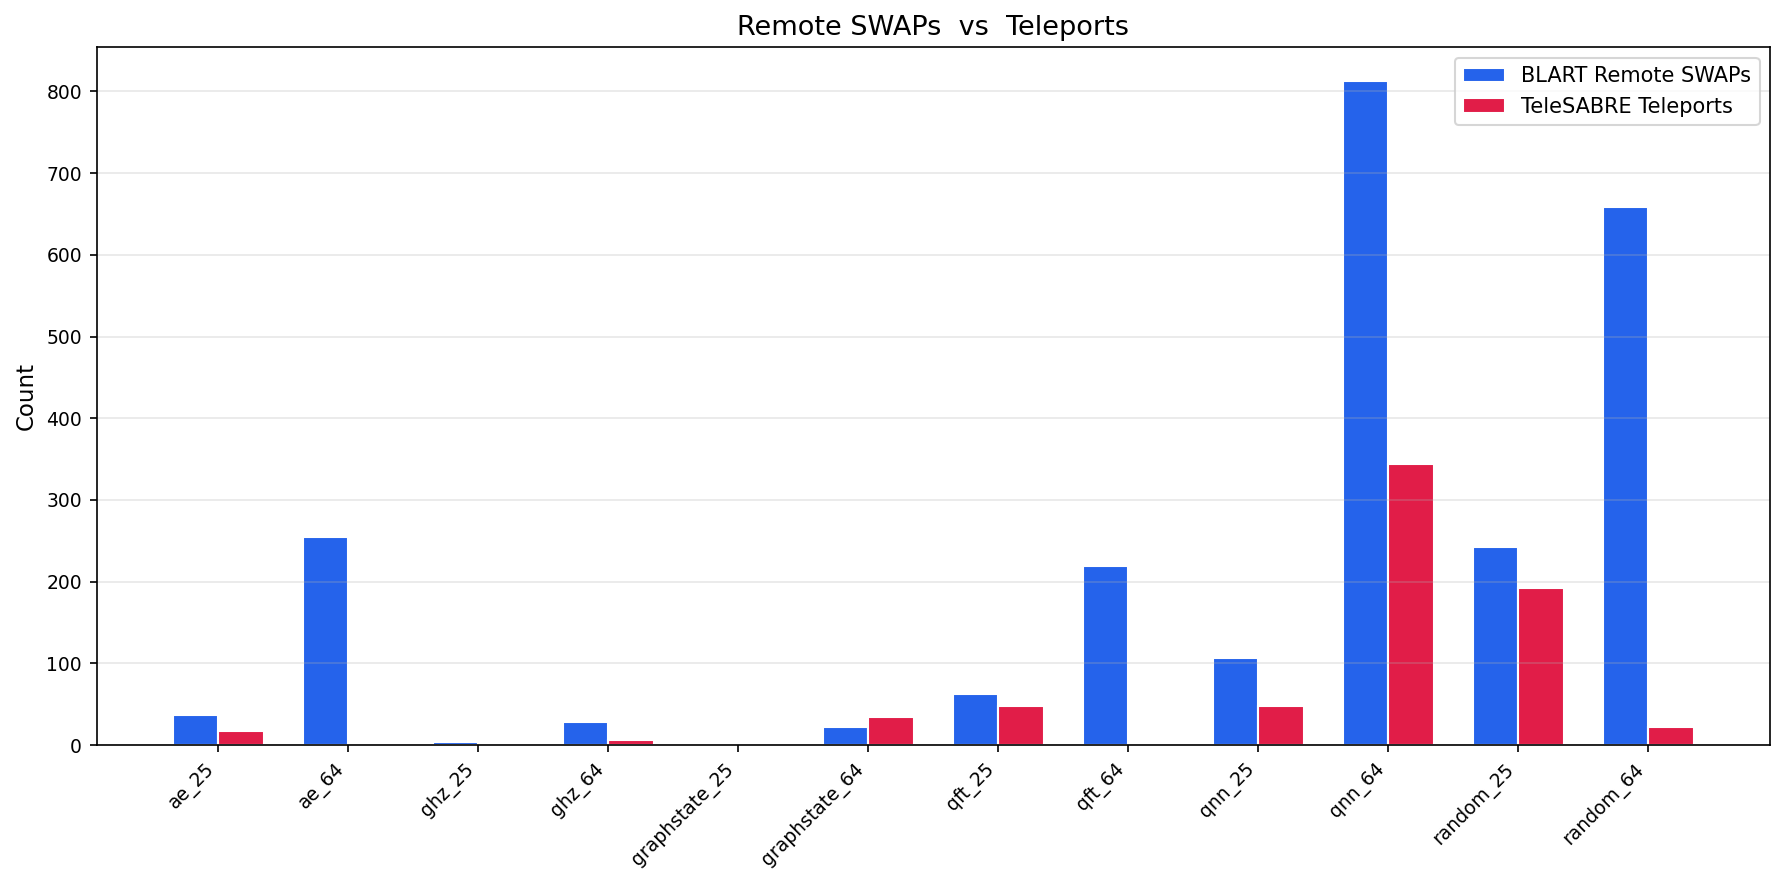

In [8]:
bar_compare(b_swaps_remote, t_teleports,
            "Count", "Remote SWAPs  vs  Teleports",
            blart_label="BLART Remote SWAPs", tele_label="TeleSABRE Teleports")

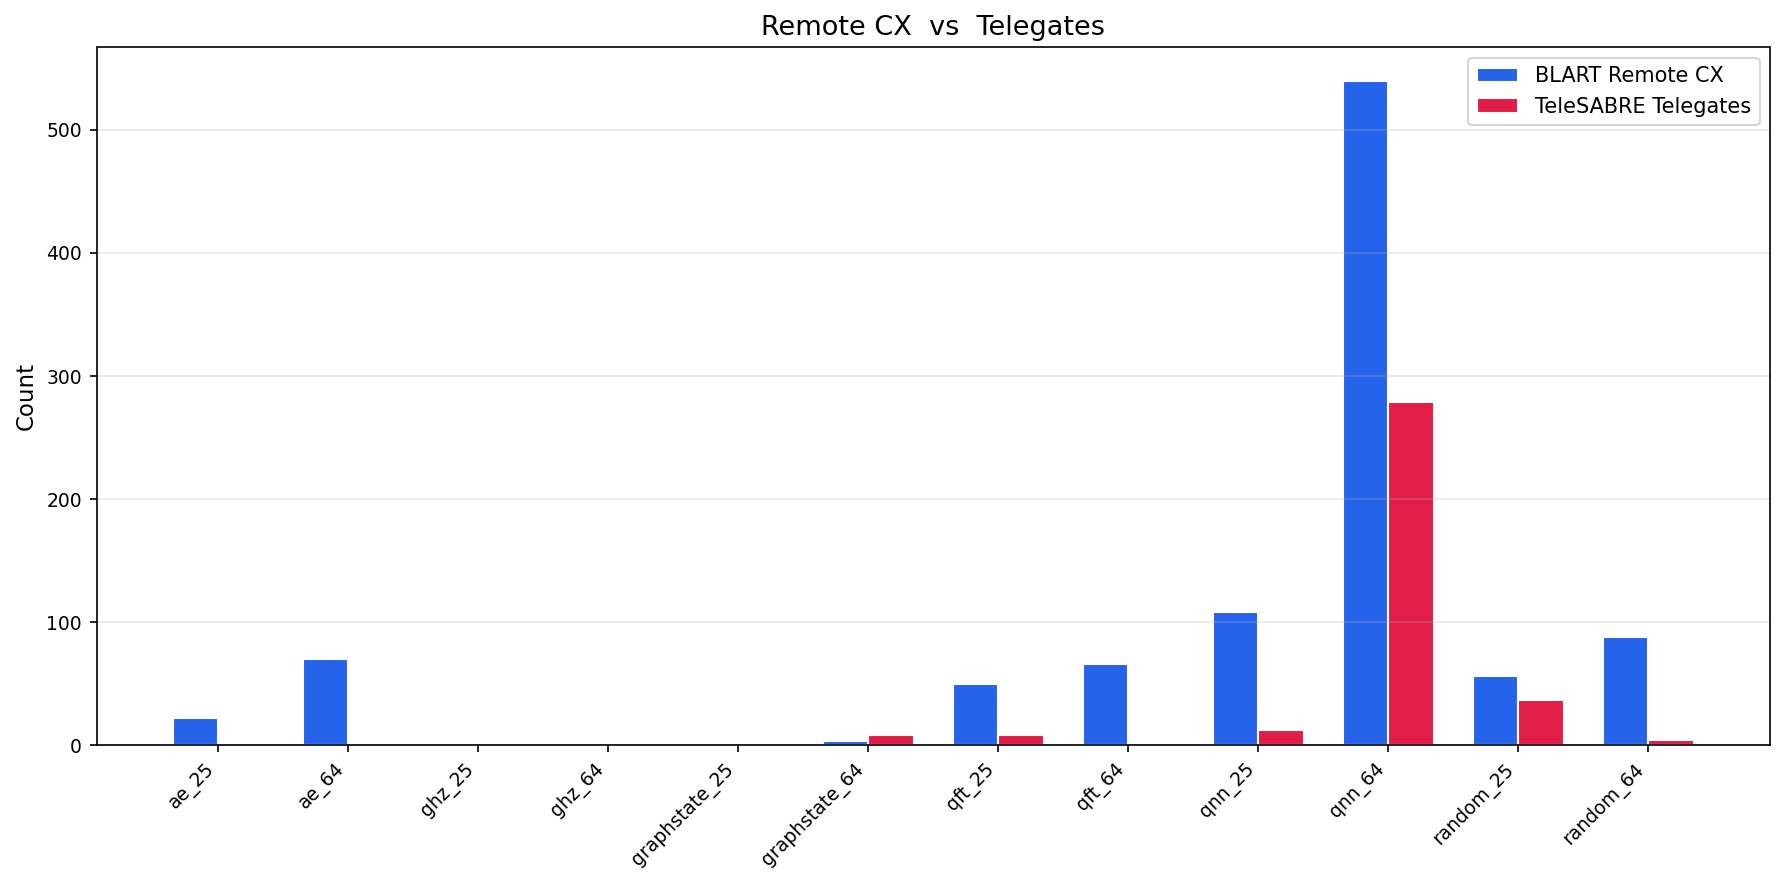

In [9]:
bar_compare(b_cx_remote, t_telegates,
            "Count", "Remote CX  vs  Telegates",
            blart_label="BLART Remote CX", tele_label="TeleSABRE Telegates")